In [3]:
# ============================================================================
# CELL 1: Import Libraries and Setup
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import cophenet
import warnings
warnings.filterwarnings('ignore')

# Set random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# ============================================================================
# CELL 2: Load and Initial Data Exploration
# ============================================================================

# Load the PFF scouting data
df = pd.read_csv('pffScoutingData.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
print(df.head())

print(f"\nBasic info:")
print(f"Total plays: {len(df):,}")
print(f"Unique games: {df['gameId'].nunique():,}")
print(f"Unique players: {df['nflId'].nunique():,}")
print(f"Unique roles: {df['pff_role'].nunique()}")

Dataset shape: (188254, 15)
Columns: ['gameId', 'playId', 'nflId', 'pff_role', 'pff_positionLinedUp', 'pff_hit', 'pff_hurry', 'pff_sack', 'pff_beatenByDefender', 'pff_hitAllowed', 'pff_hurryAllowed', 'pff_sackAllowed', 'pff_nflIdBlockedPlayer', 'pff_blockType', 'pff_backFieldBlock']

First few rows:
       gameId  playId  nflId    pff_role pff_positionLinedUp  pff_hit  \
0  2021090900      97  25511        Pass                  QB      NaN   
1  2021090900      97  35481  Pass Route                TE-L      NaN   
2  2021090900      97  35634  Pass Route                 LWR      NaN   
3  2021090900      97  39985  Pass Route                HB-R      NaN   
4  2021090900      97  40151  Pass Block                   C      NaN   

   pff_hurry  pff_sack  pff_beatenByDefender  pff_hitAllowed  \
0        NaN       NaN                   NaN             NaN   
1        NaN       NaN                   NaN             NaN   
2        NaN       NaN                   NaN             NaN   
3   

In [5]:
# ============================================================================
# CELL 3: Data Preprocessing
# ============================================================================

# Handle missing values (NA strings in PFF data)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace('NA', np.nan)

# Convert numeric columns
numeric_cols = ['pff_hit', 'pff_hurry', 'pff_sack', 'pff_beatenByDefender',
               'pff_hitAllowed', 'pff_hurryAllowed', 'pff_sackAllowed', 
               'pff_nflIdBlockedPlayer', 'pff_backFieldBlock']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df[numeric_cols].dtypes)

Data types after conversion:
pff_hit                   float64
pff_hurry                 float64
pff_sack                  float64
pff_beatenByDefender      float64
pff_hitAllowed            float64
pff_hurryAllowed          float64
pff_sackAllowed           float64
pff_nflIdBlockedPlayer    float64
pff_backFieldBlock        float64
dtype: object


In [6]:
# ============================================================================
# CELL 4: Feature Engineering
# ============================================================================

# Create engineered features
print("Creating engineered features...")

# Binary pressure features
df['had_pressure'] = (
    (df['pff_hit'].fillna(0) > 0) | 
    (df['pff_hurry'].fillna(0) > 0) | 
    (df['pff_sack'].fillna(0) > 0)
).astype(int)

df['allowed_pressure'] = (
    (df['pff_hitAllowed'].fillna(0) > 0) | 
    (df['pff_hurryAllowed'].fillna(0) > 0) | 
    (df['pff_sackAllowed'].fillna(0) > 0)
).astype(int)

# Position groupings for better analysis
position_groups = {
    'QB': 'Quarterback',
    'C': 'Offensive_Line', 'LG': 'Offensive_Line', 'RG': 'Offensive_Line',
    'LT': 'Offensive_Line', 'RT': 'Offensive_Line',
    'LWR': 'Receiver', 'RWR': 'Receiver', 'SLWR': 'Receiver', 'SRWR': 'Receiver',
    'HB': 'Running_Back', 'HB-L': 'Running_Back', 'HB-R': 'Running_Back',
    'TE-L': 'Tight_End', 'TE-R': 'Tight_End', 'TE-oL': 'Tight_End', 'TE-oR': 'Tight_End'
}

# Add defensive positions
for pos in df['pff_positionLinedUp'].unique():
    if pos not in position_groups and pd.notna(pos):
        if any(x in str(pos) for x in ['LB', 'CB', 'S', 'DL', 'LEO', 'REO', 'NT']):
            position_groups[pos] = 'Defense'

df['position_group'] = df['pff_positionLinedUp'].map(position_groups).fillna('Other')

print(f"Pressure events: {df['had_pressure'].sum():,} ({df['had_pressure'].mean():.1%})")
print(f"Position groups: {df['position_group'].value_counts()}")


Creating engineered features...
Pressure events: 4,322 (2.3%)
Position groups: position_group
Defense           88885
Offensive_Line    42783
Receiver          23181
Other             12983
Quarterback        8557
Running_Back       7170
Tight_End          4695
Name: count, dtype: int64


In [7]:
# ============================================================================
# CELL 5: Exploratory Data Analysis - Basic Statistics
# ============================================================================

print("📈 EXPLORATORY DATA ANALYSIS")
print("="*40)

# Role distribution
print("Role distribution:")
role_counts = df['pff_role'].value_counts()
print(role_counts)

# Position group distribution  
print("\nPosition group distribution:")
pos_counts = df['position_group'].value_counts()
print(pos_counts)

# Basic pressure statistics
print(f"\nPressure Statistics:")
print(f"Players who generated pressure: {df['had_pressure'].sum():,}")
print(f"Players who allowed pressure: {df['allowed_pressure'].sum():,}")
print(f"Pressure generation rate: {df['had_pressure'].mean():.1%}")


📈 EXPLORATORY DATA ANALYSIS
Role distribution:
pff_role
Coverage      57765
Pass Block    46057
Pass Route    39513
Pass Rush     36362
Pass           8557
Name: count, dtype: int64

Position group distribution:
position_group
Defense           88885
Offensive_Line    42783
Receiver          23181
Other             12983
Quarterback        8557
Running_Back       7170
Tight_End          4695
Name: count, dtype: int64

Pressure Statistics:
Players who generated pressure: 4,322
Players who allowed pressure: 2,997
Pressure generation rate: 2.3%


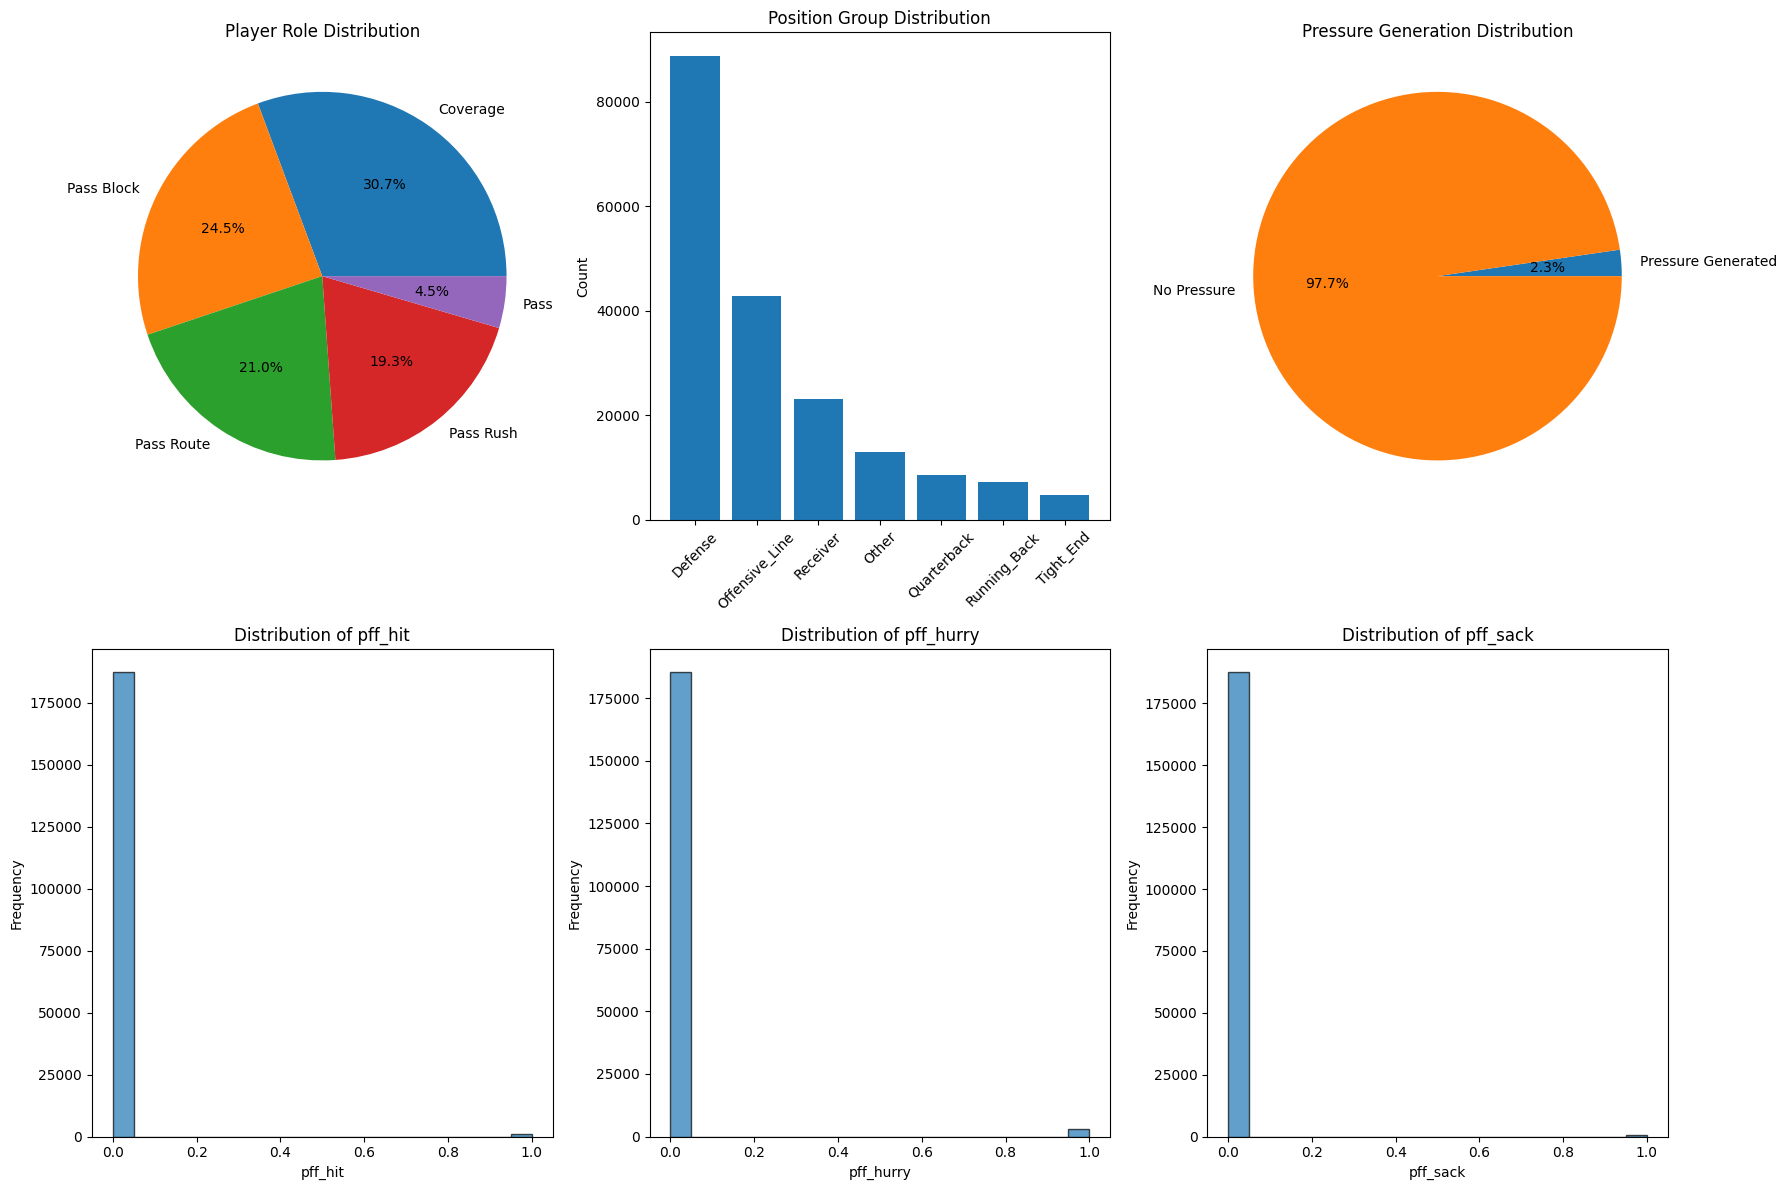

In [8]:
# ============================================================================
# CELL 6: EDA Visualizations
# ============================================================================

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Role distribution pie chart
axes[0, 0].pie(role_counts.values, labels=role_counts.index, autopct='%1.1f%%')
axes[0, 0].set_title('Player Role Distribution')

# Position group bar chart
axes[0, 1].bar(range(len(pos_counts)), pos_counts.values)
axes[0, 1].set_xticks(range(len(pos_counts)))
axes[0, 1].set_xticklabels(pos_counts.index, rotation=45)
axes[0, 1].set_title('Position Group Distribution')
axes[0, 1].set_ylabel('Count')

# Pressure generation pie chart
pressure_data = [df['had_pressure'].sum(), len(df) - df['had_pressure'].sum()]
axes[0, 2].pie(pressure_data, labels=['Pressure Generated', 'No Pressure'], autopct='%1.1f%%')
axes[0, 2].set_title('Pressure Generation Distribution')

# Individual metric distributions
numeric_features = ['pff_hit', 'pff_hurry', 'pff_sack']
for i, feature in enumerate(numeric_features):
    valid_data = df[feature].fillna(0)
    axes[1, i].hist(valid_data, bins=20, alpha=0.7, edgecolor='black')
    axes[1, i].set_title(f'Distribution of {feature}')
    axes[1, i].set_xlabel(feature)
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


🔍 Correlation Analysis


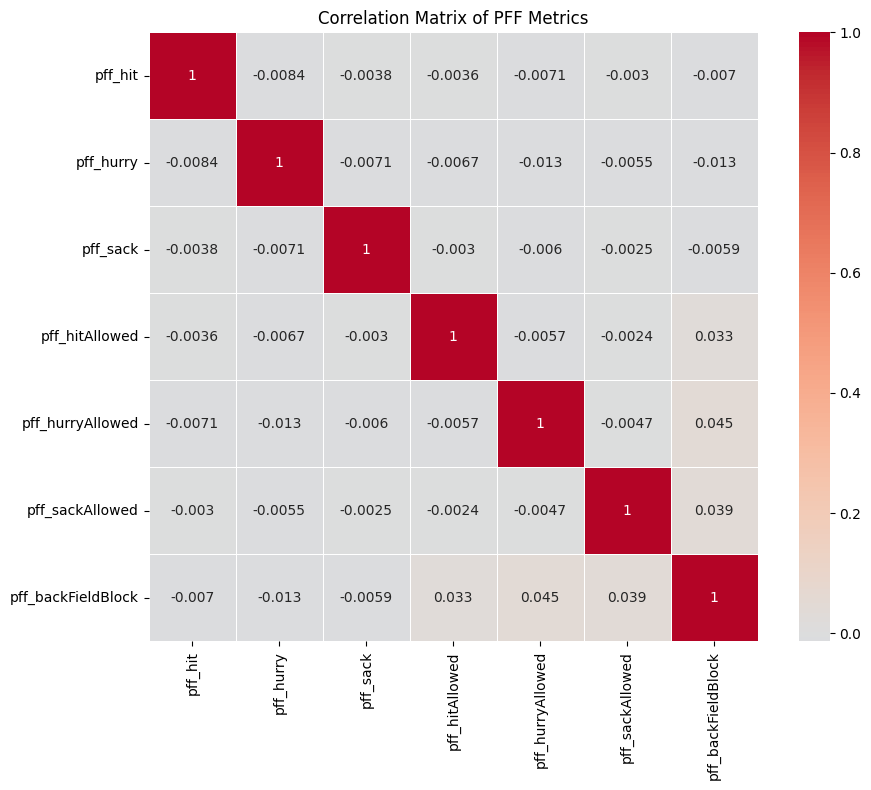

Key correlations identified:


In [9]:
# ============================================================================
# CELL 7: Correlation Analysis
# ============================================================================

# Correlation analysis of PFF metrics
print("🔍 Correlation Analysis")
numeric_cols_corr = ['pff_hit', 'pff_hurry', 'pff_sack', 'pff_hitAllowed', 
                    'pff_hurryAllowed', 'pff_sackAllowed', 'pff_backFieldBlock']

correlation_matrix = df[numeric_cols_corr].fillna(0).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of PFF Metrics')
plt.tight_layout()
plt.show()

# Print high correlations
print("Key correlations identified:")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.3:
            high_corr_pairs.append((correlation_matrix.columns[i], 
                                  correlation_matrix.columns[j], 
                                  corr_val))

for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")


In [10]:
# ============================================================================
# CELL 8: Feature Preparation for Machine Learning
# ============================================================================

print("🔨 PREPARING FEATURES FOR MACHINE LEARNING")
print("="*50)

# Initialize label encoders and feature columns
label_encoders = {}
feature_cols = ['gameId', 'playId', 'nflId']

# Encode categorical features
for col in ['pff_role', 'position_group']:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col].fillna('Unknown'))
        label_encoders[col] = le
        feature_cols.append(f'{col}_encoded')
        print(f"Encoded {col}: {len(le.classes_)} classes")

# Add numeric features
numeric_features = ['pff_hit', 'pff_hurry', 'pff_sack', 'pff_beatenByDefender',
                   'pff_hitAllowed', 'pff_hurryAllowed', 'pff_sackAllowed', 
                   'pff_backFieldBlock', 'had_pressure', 'allowed_pressure']

for col in numeric_features:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        feature_cols.append(col)

# Prepare X and y for classification
X = df[feature_cols].fillna(0)
y = df['pff_role_encoded']

print(f"Total features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols}")
print(f"Target classes: {label_encoders['pff_role'].classes_}")
print(f"Samples: {len(X):,}")


🔨 PREPARING FEATURES FOR MACHINE LEARNING
Encoded pff_role: 5 classes
Encoded position_group: 7 classes
Total features: 15
Feature columns: ['gameId', 'playId', 'nflId', 'pff_role_encoded', 'position_group_encoded', 'pff_hit', 'pff_hurry', 'pff_sack', 'pff_beatenByDefender', 'pff_hitAllowed', 'pff_hurryAllowed', 'pff_sackAllowed', 'pff_backFieldBlock', 'had_pressure', 'allowed_pressure']
Target classes: ['Coverage' 'Pass' 'Pass Block' 'Pass Route' 'Pass Rush']
Samples: 188,254


In [11]:
# ============================================================================
# CELL 9: Train-Test Split and Scaling
# ============================================================================

# Split data for modeling
print("Splitting data for modeling...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

# Check class distribution
print("\nClass distribution in training set:")
for i, class_name in enumerate(label_encoders['pff_role'].classes_):
    count = (y_train == i).sum()
    print(f"{class_name}: {count:,} ({count/len(y_train):.1%})")



Splitting data for modeling...
Training set: 150,603 samples
Test set: 37,651 samples

Class distribution in training set:
Coverage: 46,212 (30.7%)
Pass: 6,846 (4.5%)
Pass Block: 36,845 (24.5%)
Pass Route: 31,610 (21.0%)
Pass Rush: 29,090 (19.3%)


In [ ]:
# ============================================================================
# CELL 10: Week 8 - K-Nearest Neighbors Analysis
# ============================================================================

# Test different distance metrics and K values
metrics = ['euclidean', 'manhattan', 'minkowski']
k_values = [3, 5, 7, 9, 11]

print("Testing different distance metrics and K values...")
print("Metric\t\tK\tCV Accuracy")
print("-" * 40)

best_score = 0
best_params = {}
knn_results = {}

for metric in metrics:
    metric_results = {}
    for k in k_values:
        # Create KNN model
        if metric == 'minkowski':
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=2)
        else:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        
        # Cross-validation to prevent overfitting
        cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
        cv_mean = cv_scores.mean()
        
        metric_results[k] = cv_mean
        print(f"{metric:<12}\t{k}\t{cv_mean:.4f}")
        
        if cv_mean > best_score:
            best_score = cv_mean
            best_params = {'metric': metric, 'k': k}
    
    knn_results[metric] = metric_results

print(f"\n Best KNN parameters: {best_params}")
print(f"Best CV score: {best_score:.4f}")

Testing different distance metrics and K values...
Metric		K	CV Accuracy
----------------------------------------
euclidean   	3	0.9995
euclidean   	5	0.9993
euclidean   	7	0.9990
euclidean   	9	0.9987
euclidean   	11	0.9985
manhattan   	3	0.9993
manhattan   	5	0.9991
manhattan   	7	0.9989
manhattan   	9	0.9987
manhattan   	11	0.9985
minkowski   	3	0.9995
minkowski   	5	0.9993
minkowski   	7	0.9990
minkowski   	9	0.9987


In [ ]:
# ============================================================================
# CELL 10: Week 8 - K-Nearest Neighbors Analysis
# ============================================================================

# Test different distance metrics and K values
metrics = ['euclidean', 'manhattan', 'minkowski']
k_values = [3, 5, 7, 9, 11]

print("Testing different distance metrics and K values...")
print("Metric\t\tK\tCV Accuracy")
print("-" * 40)

best_score = 0
best_params = {}
knn_results = {}

for metric in metrics:
    metric_results = {}
    for k in k_values:
        # Create KNN model
        if metric == 'minkowski':
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=2)
        else:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        
        # Cross-validation to prevent overfitting
        cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
        cv_mean = cv_scores.mean()
        
        metric_results[k] = cv_mean
        print(f"{metric:<12}\t{k}\t{cv_mean:.4f}")
        
        if cv_mean > best_score:
            best_score = cv_mean
            best_params = {'metric': metric, 'k': k}
    
    knn_results[metric] = metric_results

print(f"\n🏆 Best KNN parameters: {best_params}")
print(f"Best CV score: {best_score:.4f}")

In [ ]:
# ============================================================================
# CELL 11: KNN Final Model Training and Evaluation
# ============================================================================

# Train final KNN model with best parameters
if best_params['metric'] == 'minkowski':
    final_knn = KNeighborsClassifier(n_neighbors=best_params['k'], metric='minkowski', p=2)
else:
    final_knn = KNeighborsClassifier(n_neighbors=best_params['k'], metric=best_params['metric'])

final_knn.fit(X_train_scaled, y_train)
y_pred_knn = final_knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"KNN Test Accuracy: {knn_accuracy:.4f}")
print(f"CV vs Test difference: {abs(knn_accuracy - best_score):.4f}")

# Classification report
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=label_encoders['pff_role'].classes_))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
           xticklabels=label_encoders['pff_role'].classes_,
           yticklabels=label_encoders['pff_role'].classes_)
plt.title('KNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================================
# CELL 12: Week 9 - Gradient Boosting Analysis
# ============================================================================

# Define hyperparameter grid for comprehensive tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

print("Hyperparameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")
print(f"Total combinations: {np.prod([len(v) for v in param_grid.values()])}")

# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=RANDOM_STATE)

print("\nPerforming hyperparameter tuning with 5-fold cross-validation...")
grid_search = GridSearchCV(
    gb_model, 
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

In [ ]:
# ============================================================================
# CELL 13: Gradient Boosting Model Evaluation
# ============================================================================

# Train final model and evaluate
best_gb = grid_search.best_estimator_
y_pred_gb = best_gb.predict(X_test_scaled)
gb_accuracy = accuracy_score(y_test, y_pred_gb)

print(f"Gradient Boosting Test Accuracy: {gb_accuracy:.4f}")
print(f"CV vs Test difference: {abs(gb_accuracy - grid_search.best_score_):.4f}")

# Detailed classification report
print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb, target_names=label_encoders['pff_role'].classes_))

# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_gb.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 15 Feature Importances:")
print(feature_importance.head(15))

In [ ]:
# ============================================================================
# CELL 14: Feature Importance Visualization
# ============================================================================

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - Gradient Boosting')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Confusion matrix for Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens',
           xticklabels=label_encoders['pff_role'].classes_,
           yticklabels=label_encoders['pff_role'].classes_)
plt.title('Gradient Boosting Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 15: Week 10 - K-Means Clustering Preparation
# ============================================================================

# Prepare data specifically for clustering (unsupervised)
clustering_features = ['pff_hit', 'pff_hurry', 'pff_sack', 'pff_hitAllowed', 
                      'pff_hurryAllowed', 'pff_sackAllowed', 'pff_backFieldBlock',
                      'had_pressure', 'allowed_pressure']

# Create clustering dataset
cluster_data = df[clustering_features].fillna(0)
cluster_data_scaled = StandardScaler().fit_transform(cluster_data)

print(f"Clustering dataset prepared:")
print(f"Features: {clustering_features}")
print(f"Samples: {len(cluster_data):,}")

# Sample for computational efficiency if dataset is very large
if len(cluster_data) > 20000:
    sample_size = 20000
    sample_indices = np.random.choice(len(cluster_data), sample_size, replace=False)
    cluster_data_scaled_sample = cluster_data_scaled[sample_indices]
    print(f"Sampled {sample_size:,} points for clustering analysis")
else:
    cluster_data_scaled_sample = cluster_data_scaled
    print(f"Using full dataset for clustering")

In [ ]:
# ============================================================================
# CELL 16: K-Means Optimal Cluster Selection
# ============================================================================

# Find optimal number of clusters using silhouette score
k_range = range(2, 11)
silhouette_scores = []
inertias = []

print("Finding optimal number of clusters...")
print("K\tSilhouette\tInertia")
print("-" * 30)

for k in k_range:
    # Fit K-means
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans.fit_predict(cluster_data_scaled_sample)
    
    # Calculate metrics
    silhouette_avg = silhouette_score(cluster_data_scaled_sample, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    inertias.append(kmeans.inertia_)
    
    print(f"{k}\t{silhouette_avg:.4f}\t\t{kmeans.inertia_:.0f}")

# Find optimal K
optimal_k = k_range[np.argmax(silhouette_scores)]
best_silhouette = max(silhouette_scores)

print(f"\n Optimal number of clusters: {optimal_k}")
print(f"Best silhouette score: {best_silhouette:.4f}")

In [ ]:
# ============================================================================
# CELL 17: K-Means Final Clustering and Analysis
# ============================================================================

# Perform final clustering with optimal K
final_kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)

# Cluster on full dataset
cluster_labels = final_kmeans.fit_predict(cluster_data_scaled)

# Add cluster labels to original dataframe
df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print(f"Final clustering completed with K={optimal_k}")
print(f"Final silhouette score: {silhouette_score(cluster_data_scaled_sample, final_kmeans.predict(cluster_data_scaled_sample)):.4f}")

# Analyze cluster sizes
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print(f"\nCluster sizes:")
for cluster, size in cluster_sizes.items():
    print(f"Cluster {cluster}: {size:,} players ({size/len(cluster_labels):.1%})")

# Detailed cluster analysis
print(f"\n Detailed Cluster Analysis:")
for i in range(optimal_k):
    cluster_subset = df_clustered[df_clustered['cluster'] == i]
    print(f"\nCluster {i} ({len(cluster_subset):,} players):")
    
    if len(cluster_subset) > 0:
        most_common_role = cluster_subset['pff_role'].mode()
        most_common_position = cluster_subset['position_group'].mode()
        
        print(f"  Most common role: {most_common_role.iloc[0] if len(most_common_role) > 0 else 'N/A'}")
        print(f"  Most common position group: {most_common_position.iloc[0] if len(most_common_position) > 0 else 'N/A'}")
        print(f"  Average pressure generated: {cluster_subset['had_pressure'].mean():.3f}")
        print(f"  Average pressure allowed: {cluster_subset['allowed_pressure'].mean():.3f}")


In [ ]:
# ============================================================================
# CELL 18: K-Means Visualization
# ============================================================================

# Visualize clustering metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Silhouette scores
axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(optimal_k, color='red', linestyle='--', alpha=0.7, 
               label=f'Optimal K={optimal_k}')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs Number of Clusters')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Elbow method (inertia)
axes[1].plot(k_range, inertias, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(optimal_k, color='red', linestyle='--', alpha=0.7,
               label=f'Silhouette Optimal K={optimal_k}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[1].set_title('Elbow Method')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Additional cluster visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Cluster sizes
axes[0, 0].bar(cluster_sizes.index, cluster_sizes.values)
axes[0, 0].set_title('Cluster Sizes')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Number of Players')

# Pressure generation by cluster
pressure_by_cluster = df_clustered.groupby('cluster')['had_pressure'].mean()
axes[0, 1].bar(pressure_by_cluster.index, pressure_by_cluster.values)
axes[0, 1].set_title('Average Pressure Generation by Cluster')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Pressure Generation Rate')

# Role distribution across clusters
role_cluster_crosstab = pd.crosstab(df_clustered['cluster'], df_clustered['pff_role'], normalize='index')
role_cluster_crosstab.plot(kind='bar', stacked=True, ax=axes[1, 0])
axes[1, 0].set_title('Role Distribution by Cluster')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Position group distribution
pos_cluster_crosstab = pd.crosstab(df_clustered['cluster'], df_clustered['position_group'], normalize='index')
pos_cluster_crosstab.plot(kind='bar', stacked=True, ax=axes[1, 1])
axes[1, 1].set_title('Position Group Distribution by Cluster')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Proportion')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 19: Week 11 - DBSCAN and Hierarchical Clustering Setup
# ============================================================================

# Prepare data (sample for computational efficiency)
sample_size = min(10000, len(df))
sample_indices = np.random.choice(len(df), sample_size, replace=False)

cluster_data_sample = df.iloc[sample_indices][clustering_features].fillna(0)
cluster_data_sample_scaled = StandardScaler().fit_transform(cluster_data_sample)

print(f"Sample prepared for density clustering:")
print(f"Sample size: {sample_size:,}")
print(f"Features: {len(clustering_features)}")
print(f"Data shape: {cluster_data_sample_scaled.shape}")

In [ ]:
# ============================================================================
# CELL 20: DBSCAN Parameter Optimization
# ============================================================================


eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [5, 10, 15]

best_dbscan = None
best_silhouette_dbscan = -1
best_params_dbscan = {}
dbscan_results = []

print("eps\tmin_samples\tn_clusters\tn_noise\tsilhouette")
print("-" * 50)

for eps in eps_values:
    for min_samples in min_samples_values:
        # Fit DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        cluster_labels = dbscan.fit_predict(cluster_data_sample_scaled)
        
        # Calculate metrics
        n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        n_noise = list(cluster_labels).count(-1)
        noise_pct = n_noise / len(cluster_labels) * 100
        
        # Calculate silhouette score (only if we have clusters)
        if n_clusters > 1:
            # Remove noise points for silhouette calculation
            mask = cluster_labels != -1
            if mask.sum() > 0:
                silhouette_avg = silhouette_score(cluster_data_sample_scaled[mask], 
                                                 cluster_labels[mask])
            else:
                silhouette_avg = -1
        else:
            silhouette_avg = -1
        
        # Store results
        result = {
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': noise_pct,
            'silhouette': silhouette_avg,
            'labels': cluster_labels
        }
        dbscan_results.append(result)
        
        print(f"{eps}\t{min_samples}\t\t{n_clusters}\t\t{n_noise}\t{silhouette_avg:.4f}")
        
        # Track best parameters
        if silhouette_avg > best_silhouette_dbscan and n_clusters > 1:
            best_silhouette_dbscan = silhouette_avg
            best_dbscan = dbscan
            best_params_dbscan = {'eps': eps, 'min_samples': min_samples}
            best_dbscan_labels = cluster_labels

print(f"\n Best DBSCAN parameters: {best_params_dbscan}")
print(f"Best silhouette score: {best_silhouette_dbscan:.4f}")

In [ ]:
# ============================================================================
# CELL 21: Hierarchical Clustering Analysis
# ============================================================================


# Use smaller sample for hierarchical clustering (computational efficiency)
hier_sample_size = min(1000, len(cluster_data_sample_scaled))
hier_indices = np.random.choice(len(cluster_data_sample_scaled), hier_sample_size, replace=False)
hier_data = cluster_data_sample_scaled[hier_indices]

print(f"Hierarchical clustering sample size: {hier_sample_size}")

# Perform hierarchical clustering
linkage_matrix = linkage(hier_data, method='ward')

# Calculate cophenetic correlation
c, coph_dists = cophenet(linkage_matrix, pdist(hier_data))
print(f"Cophenetic correlation coefficient: {c:.4f}")

if c > 0.7:
    print("High cophenetic correlation - hierarchical structure is well-preserved")
elif c > 0.5:
    print("Moderate cophenetic correlation - reasonable hierarchical structure")
else:
    print("Low cophenetic correlation - hierarchical structure may not be ideal")

# Visualize hierarchical clustering
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, 
          truncate_mode='level', 
          p=5,  # Show top 5 levels
          show_leaf_counts=True,
          leaf_font_size=10)

plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Determine optimal number of clusters from dendrogram
distances = linkage_matrix[:, 2]
distance_diffs = np.diff(distances)
optimal_hier_clusters = len(distances) - np.argmax(distance_diffs[-10:]) + 1

print(f"\nSuggested number of clusters from dendrogram: {optimal_hier_clusters}")

# Get hierarchical cluster labels
n_clusters_hier = min(5, optimal_hier_clusters)  # Limit to reasonable number
hier_labels = fcluster(linkage_matrix, n_clusters_hier, criterion='maxclust')

print(f"Using {n_clusters_hier} clusters for analysis")

# Calculate silhouette for hierarchical clustering
hier_silhouette = silhouette_score(hier_data, hier_labels)
print(f"Hierarchical clustering silhouette score: {hier_silhouette:.4f}")

In [ ]:
# ============================================================================
# CELL 22: Clustering Methods Comparison
# ============================================================================

# Results summary
comparison_data = {
    'Method': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'Optimal_Clusters': [optimal_k, len(set(best_dbscan_labels)) - (1 if -1 in best_dbscan_labels else 0), n_clusters_hier],
    'Silhouette_Score': [best_silhouette, best_silhouette_dbscan, hier_silhouette],
    'Handles_Noise': ['No', 'Yes', 'No'],
    'Cluster_Shape': ['Spherical', 'Arbitrary', 'Hierarchical']
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Analyze DBSCAN noise points
n_noise_best = list(best_dbscan_labels).count(-1)
noise_pct_best = n_noise_best / len(best_dbscan_labels) * 100

print(f"\nDBSCAN Noise Analysis:")
print(f"Noise points identified: {n_noise_best} ({noise_pct_best:.1f}%)")

if noise_pct_best > 10:
    print("High percentage of noise points suggests significant performance variability")
elif noise_pct_best > 5:
    print("Moderate noise level indicates some outlier performances")
else:
    print("Low noise level suggests most players fit standard performance patterns")

In [ ]:
# ============================================================================
# CELL 23: Clustering Comparison Visualizations
# ============================================================================

# Visualize clustering comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# DBSCAN results visualization
dbscan_df = pd.DataFrame(dbscan_results)

# DBSCAN parameter heatmap - silhouette scores
pivot_silhouette = dbscan_df.pivot(index='min_samples', columns='eps', values='silhouette')
sns.heatmap(pivot_silhouette, annot=True, fmt='.3f', cmap='viridis', ax=axes[0, 0])
axes[0, 0].set_title('DBSCAN Silhouette Scores')
axes[0, 0].set_xlabel('eps')
axes[0, 0].set_ylabel('min_samples')

# DBSCAN noise percentage
pivot_noise = dbscan_df.pivot(index='min_samples', columns='eps', values='noise_pct')
sns.heatmap(pivot_noise, annot=True, fmt='.1f', cmap='Reds', ax=axes[0, 1])
axes[0, 1].set_title('DBSCAN Noise Percentage')
axes[0, 1].set_xlabel('eps')
axes[0, 1].set_ylabel('min_samples')

# Clustering method comparison
methods = ['K-Means', 'DBSCAN', 'Hierarchical']
silhouette_scores_comp = [best_silhouette, best_silhouette_dbscan, hier_silhouette]

axes[1, 0].bar(methods, silhouette_scores_comp, color=['skyblue', 'lightgreen', 'salmon'])
axes[1, 0].set_title('Silhouette Score Comparison')
axes[1, 0].set_ylabel('Silhouette Score')
axes[1, 0].set_ylim(0, max(silhouette_scores_comp) * 1.1)

# Add values on bars
for i, v in enumerate(silhouette_scores_comp):
    axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# Cluster count comparison
cluster_counts = [optimal_k, 
                 len(set(best_dbscan_labels)) - (1 if -1 in best_dbscan_labels else 0),
                 n_clusters_hier]

axes[1, 1].bar(methods, cluster_counts, color=['skyblue', 'lightgreen', 'salmon'])
axes[1, 1].set_title('Number of Clusters Identified')
axes[1, 1].set_ylabel('Number of Clusters')

# Add values on bars
for i, v in enumerate(cluster_counts):
    axes[1, 1].text(i, v + 0.1, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 25: Final Comprehensive Visualization
# ============================================================================

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Classification model accuracy comparison
classification_models = ['K-Nearest Neighbors', 'Gradient Boosting']
accuracies = [knn_accuracy, gb_accuracy]
cv_scores = [best_score, grid_search.best_score_]

x_pos = np.arange(len(classification_models))
width = 0.35

axes[0, 0].bar(x_pos - width/2, accuracies, width, label='Test Accuracy', alpha=0.8)
axes[0, 0].bar(x_pos + width/2, cv_scores, width, label='CV Accuracy', alpha=0.8)
axes[0, 0].set_title('Classification Model Performance')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(classification_models)
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1)

# Add values on bars
for i, (acc, cv) in enumerate(zip(accuracies, cv_scores)):
    axes[0, 0].text(i - width/2, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom')
    axes[0, 0].text(i + width/2, cv + 0.01, f'{cv:.3f}', ha='center', va='bottom')

# Clustering silhouette comparison
clustering_methods = ['K-Means', 'DBSCAN', 'Hierarchical']
clustering_silhouettes = [best_silhouette, best_silhouette_dbscan, hier_silhouette]

axes[0, 1].bar(clustering_methods, clustering_silhouettes, 
              color=['skyblue', 'lightgreen', 'salmon'])
axes[0, 1].set_title('Clustering Method Silhouette Scores')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].tick_params(axis='x', rotation=45)

for i, v in enumerate(clustering_silhouettes):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# Feature importance (top 10)
top_10_features = feature_importance.head(10)
axes[0, 2].barh(range(len(top_10_features)), top_10_features['importance'])
axes[0, 2].set_yticks(range(len(top_10_features)))
axes[0, 2].set_yticklabels(top_10_features['feature'])
axes[0, 2].set_title('Top 10 Feature Importances')
axes[0, 2].set_xlabel('Importance')

# Role distribution in dataset
role_counts = df['pff_role'].value_counts()
axes[1, 0].pie(role_counts.values, labels=role_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Player Role Distribution')

# Cluster sizes comparison
kmeans_sizes = df_clustered['cluster'].value_counts().sort_index()
axes[1, 1].bar(range(len(kmeans_sizes)), kmeans_sizes.values)
axes[1, 1].set_title('K-Means Cluster Sizes')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Number of Players')

# Performance metrics correlation
perf_metrics = ['pff_hit', 'pff_hurry', 'pff_sack', 'had_pressure']
perf_corr = df[perf_metrics].fillna(0).corr()
sns.heatmap(perf_corr, annot=True, cmap='coolwarm', center=0, ax=axes[1, 2])
axes[1, 2].set_title('Performance Metrics Correlation')

plt.tight_layout()
plt.show()
